# The Simplex Method

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/DEV/L07/L07_simplex_method.ipynb)
### MECH 559 - Systems Optimization - L07

Companion notebook to the second half of the "Linear programming" lecture. We build the simplex method from scratch: canonical form, the pivot formulas, Dantzig's rule for choosing the entering variable, and the minimum-ratio test for the leaving variable - then reproduce the farmer's-problem tableau sequence exactly as worked in the slides, and use the implementation on a second problem.

See `L07_lp_formulation_and_basic_solutions.ipynb` first if you have not already - this notebook assumes you know what a basic (feasible) solution is and why brute-force enumeration does not scale.

## Learning objectives

By the end, students should be able to:

1. Implement the Gauss-Jordan pivot formulas and verify a pivot always leaves the rest of the identity structure intact.
2. Implement the full simplex algorithm (entering-variable rule, ratio test, termination test) from scratch.
3. Reproduce the farmer's-problem tableau sequence from the lecture ($k=0,1,2$) and the vertex path $(0,0)\to(160,0)\to(80,160)$.
4. Cross-check a from-scratch simplex implementation against `scipy.optimize.linprog`.
5. Recognize when a problem is *not* immediately ready for this simplex implementation (no all-slack starting basis) and know, at a conceptual level, what a two-phase/Big-M method would need to do about it.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49", "path": "#3F88C5"}

print(f"NumPy {np.__version__}; SciPy available for cross-checks")

NumPy 2.5.0; SciPy available for cross-checks


---
## 1. Pivoting: swapping a basic and a non-basic variable

Given a canonical tableau with pivot element $y_{pq}\ne0$ (row $p$, column $q$), the Gauss-Jordan pivot formulas are:

$$
\hat y_{pj}=\frac{y_{pj}}{y_{pq}}, \qquad \hat y_{ij}=y_{ij}-\frac{y_{pj}}{y_{pq}}y_{iq}\;\;\forall i\ne p
$$

This normalizes row $p$ and eliminates column $q$ everywhere else, exactly like a Gauss-Jordan elimination step.

In [3]:
def pivot(A, b, p, q):
    '''One Gauss-Jordan pivot on tableau (A|b) at row p, column q. Returns new (A, b).'''
    A = A.copy()
    b = b.copy()
    pivot_val = A[p, q]
    A[p, :] = A[p, :] / pivot_val
    b[p] = b[p] / pivot_val
    for i in range(A.shape[0]):
        if i != p:
            factor = A[i, q]
            A[i, :] = A[i, :] - factor * A[p, :]
            b[i] = b[i] - factor * b[p]
    return A, b

# Sanity check: pivoting on a column that is already a unit vector changes nothing
A_test = np.array([[1., 0., 2.], [0., 1., 3.]])
b_test = np.array([5., 7.])
A_new, b_new = pivot(A_test, b_test, p=0, q=0)
assert np.allclose(A_new, A_test) and np.allclose(b_new, b_test)
print("Pivoting on an existing unit column leaves the tableau unchanged, as expected.")

# Pivot the farmer's initial tableau on (p=0, q=0): swap s1 out, x1 in
A0 = np.array([[2., 1., 1., 0.], [1., 1., 0., 1.]])
b0 = np.array([320., 240.])
A1, b1 = pivot(A0, b0, p=0, q=0)
print("\nAfter pivoting on (row 0, col 0):")
print(pd.DataFrame(np.column_stack([A1, b1]), columns=["x1", "x2", "s1", "s2", "y0i"]))

Pivoting on an existing unit column leaves the tableau unchanged, as expected.

After pivoting on (row 0, col 0):
    x1   x2   s1   s2    y0i
0  1.0  0.5  0.5  0.0  160.0
1  0.0  0.5 -0.5  1.0   80.0


> **Predict:** column `x1` above should now be a unit vector (1 in row 0, 0 elsewhere) - that is what "$x_1$ is now basic in row 0" means. Check that it is, then predict what pivoting again on `(row 1, col 1)` will do to the `x2` column before running further cells below.

---
## 2. The full simplex algorithm

Following the lecture's steps:

1. Start from a feasible basic solution (tableau).
2. If $r_j\ge0\;\forall j$, stop - optimal.
3. Otherwise choose the entering column $q=\arg\max_q|r_q|$ subject to $r_q<0$ (Dantzig's rule).
4. Ratio test: among rows with $y_{iq}>0$, the leaving row is $p=\arg\min_i y_{0i}/y_{iq}$ (unbounded if no such row exists).
5. Pivot on $y_{pq}$ and repeat.

We keep a full history of every tableau visited so we can display and plot the iterations afterwards.

In [4]:
def simplex_tableau(A, b, c, basis, names=None, max_iter=100):
    '''Dantzig-rule simplex on an initial canonical tableau (A, b) with the
    given starting `basis` (list of column indices forming the identity).
    Assumes b >= 0, i.e. the starting basis is already feasible.
    Returns (x*, objective*, history) where history is a list of per-iteration
    tableau snapshots (A, b, reduced costs r, f0, basis, and the (p, q) pivot used).'''
    A = np.asarray(A, float).copy()
    b = np.asarray(b, float).copy()
    c = np.asarray(c, float).copy()
    m, n = A.shape
    basis = list(basis)
    names = names or [f"x{j+1}" for j in range(n)]
    assert np.all(b >= -1e-9), "starting basis is not feasible (some b_i < 0) - needs Big-M / two-phase"

    history = []
    for k in range(max_iter):
        cB = c[basis]
        f = cB @ A                      # f_j = sum_i y_ij c_i, for every column j
        r = c - f                       # reduced costs r_j = c_j - f_j
        f0 = float(cB @ b)
        entry = {"k": k, "A": A.copy(), "b": b.copy(), "r": r.copy(), "f0": f0, "basis": list(basis)}

        neg = np.where(r < -1e-9)[0]
        if len(neg) == 0:
            entry["pivot"] = None
            history.append(entry)
            break                        # optimal: no negative reduced cost left

        q = neg[np.argmax(np.abs(r[neg]))]          # Dantzig's rule
        pos_rows = np.where(A[:, q] > 1e-9)[0]
        if len(pos_rows) == 0:
            raise RuntimeError(f"problem is unbounded below (column {names[q]} has no positive entry)")
        ratios = b[pos_rows] / A[pos_rows, q]
        p = pos_rows[np.argmin(ratios)]              # minimum-ratio test
        entry["pivot"] = (int(p), int(q))
        history.append(entry)

        A, b = pivot(A, b, p, q)
        basis[p] = q

    x = np.zeros(n)
    for i, col in enumerate(basis):
        x[col] = b[i]
    obj = float(c @ x)
    return x, obj, history

---
## 3. The farmer's problem, step by step

Same standard-form data as the previous notebook: variables $[x_1,x_2,s_1,s_2]$, starting basis $\{s_1,s_2\}$ (the all-slack basis, always a valid feasible start when $b\ge0$).

In [5]:
def show_tableau(entry, names):
    m = len(entry["basis"])
    cols = names + ["y0i"]
    rows = [f"basic: {names[entry['basis'][i]]}" for i in range(m)]
    data = np.column_stack([entry["A"], entry["b"]])
    df = pd.DataFrame(data, index=rows, columns=cols)
    r_row = pd.DataFrame([list(entry["r"]) + [np.nan]], index=["r_j=c_j-f_j"], columns=cols)
    return pd.concat([df, r_row])

names = ["x1", "x2", "s1", "s2"]
A = [[2, 1, 1, 0], [1, 1, 0, 1]]
b = [320, 240]
c = [-40, -30, 0, 0]

x_star, obj_star, history = simplex_tableau(A, b, c, basis=[2, 3], names=names)

for h in history:
    tag = f"pivot on (row {h['pivot'][0]}, col {names[h['pivot'][1]]})" if h["pivot"] else "OPTIMAL - stop"
    print(f"=== k={h['k']}  (f0 = {h['f0']:.1f})  ->  {tag} ===")
    display(show_tableau(h, names))

print(f"\nx* = {x_star}, objective* = {obj_star}")
assert np.allclose(x_star, [80, 160, 0, 0]) and np.isclose(obj_star, -8000)
print("Matches the lecture exactly: q=1 (col x1) then p=1 (row s1) at k=0; q=2 (col x2) then p=2 (row s2) at k=1.")

=== k=0  (f0 = 0.0)  ->  pivot on (row 0, col x1) ===


,x1,x2,s1,s2,y0i
basic: s1,2.0,1.0,1.0,0.0,320.0
basic: s2,1.0,1.0,0.0,1.0,240.0
r_j=c_j-f_j,-40.0,-30.0,0.0,0.0,NaN


=== k=1  (f0 = -6400.0)  ->  pivot on (row 1, col x2) ===


,x1,x2,s1,s2,y0i
basic: x1,1.0,0.5,0.5,0.0,160.0
basic: s2,0.0,0.5,-0.5,1.0,80.0
r_j=c_j-f_j,0.0,-10.0,20.0,0.0,NaN


=== k=2  (f0 = -8000.0)  ->  OPTIMAL - stop ===


,x1,x2,s1,s2,y0i
basic: x1,1.0,0.0,1.0,-1.0,80.0
basic: x2,0.0,1.0,-1.0,2.0,160.0
r_j=c_j-f_j,0.0,0.0,10.0,20.0,NaN



x* = [ 80. 160.   0.   0.], objective* = -8000.0
Matches the lecture exactly: q=1 (col x1) then p=1 (row s1) at k=0; q=2 (col x2) then p=2 (row s2) at k=1.


### Visualizing the path

Each tableau corresponds to a vertex of the feasible polytope. Let's extract $(x_1,x_2)$ at every iteration and draw the path simplex actually took, on top of the feasible region.

Vertex path visited by simplex: [(np.float64(0.0), np.float64(0.0)), (np.float64(160.0), np.float64(0.0)), (np.float64(80.0), np.float64(160.0))]


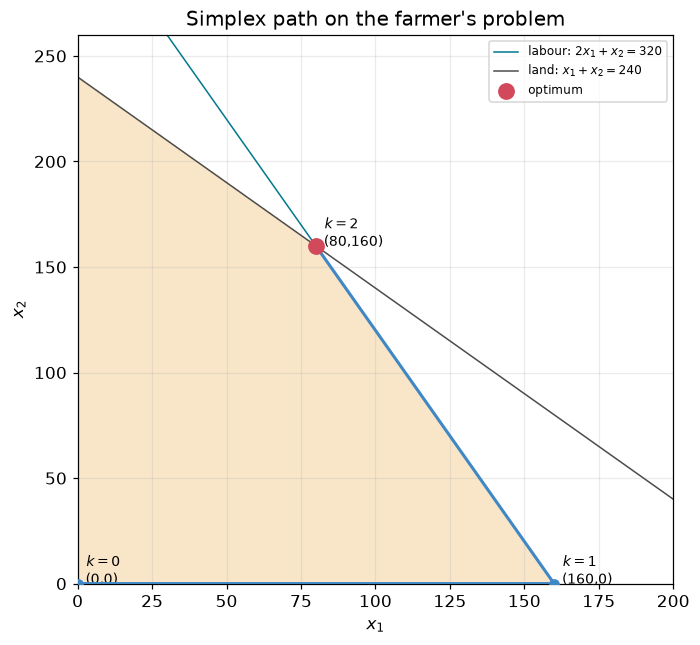

In [6]:
path = []
for h in history:
    xk = np.zeros(4)
    for i, col in enumerate(h["basis"]):
        xk[col] = h["b"][i]
    path.append(xk[:2])
path = np.array(path)
print("Vertex path visited by simplex:", [tuple(p) for p in path])

X1, X2 = np.meshgrid(np.linspace(0, 200, 400), np.linspace(0, 260, 400))
feasible = (2*X1 + X2 <= 320) & (X1 + X2 <= 240) & (X1 >= 0) & (X2 >= 0)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1], colors=[COLORS["accent"]], alpha=0.3)
x1g = np.linspace(0, 200, 400)
ax.plot(x1g, 320 - 2*x1g, color=COLORS["boundary"], lw=1, label="labour: $2x_1+x_2=320$")
ax.plot(x1g, 240 - x1g, color="0.3", lw=1, label="land: $x_1+x_2=240$")

ax.plot(path[:, 0], path[:, 1], "-o", color=COLORS["path"], lw=2, zorder=5)
for k, (x1v, x2v) in enumerate(path):
    ax.annotate(f"  $k={k}$\n  ({x1v:.0f},{x2v:.0f})", (x1v, x2v), fontsize=9)
ax.scatter(*path[-1], color=COLORS["optimum"], s=100, zorder=6, label="optimum")

ax.set(xlim=(0, 200), ylim=(0, 260), xlabel="$x_1$", ylabel="$x_2$",
       title="Simplex path on the farmer's problem")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

### Cross-check against `scipy.optimize.linprog`

Our from-scratch tableau simplex should agree exactly with a production LP solver.

In [7]:
res = linprog([-40, -30], A_ub=[[2, 1], [1, 1]], b_ub=[320, 240],
              bounds=[(0, None), (0, None)], method="highs")
print("scipy.optimize.linprog:", res.x, res.fun)
print("our simplex_tableau  :", x_star[:2], obj_star)
assert np.allclose(res.x, x_star[:2]) and np.isclose(res.fun, obj_star)
print("\nAgreement confirmed.")

scipy.optimize.linprog: [ 80. 160.] -8000.0
our simplex_tableau  : [ 80. 160.] -8000.0

Agreement confirmed.


---
## 4. A second problem - and a limitation to be aware of

The lecture closes with a second LP (see the GitHub notebook link on that slide):

$$
\min\; f(\mathbf z)=-x_1+x_2 \quad\text{s.t.}\quad 2x_1+3x_2\le10,\;\; -5x_1-2x_2\le-2,\;\; -2x_1+7x_2\le8,\;\; x_1\le5,\;\; x_2\ge-5
$$

Notice this problem does **not** give $x_1,x_2\ge0$ - and if you add slack/surplus variables and check the origin ($x_1=x_2=0$), the second constraint $-5x_1-2x_2\le-2$ is *violated* at the origin ($0\le-2$ is false). That means the natural "start from the all-slack basis" trick our `simplex_tableau` uses does **not** give a feasible starting tableau here.

> **Predict:** what do you think must happen before our from-scratch simplex could even take its first step on this problem?

This is exactly the gap that a **two-phase** or **Big-M** simplex method fills (finding *any* feasible starting basis first) - a topic for a later lecture, not this one. For now we solve it with `scipy.optimize.linprog`, which handles this internally, and visualize the result the same way we did by hand for the farmer's problem.

optimal x* = [ 5. -5.]  f* = -10.0


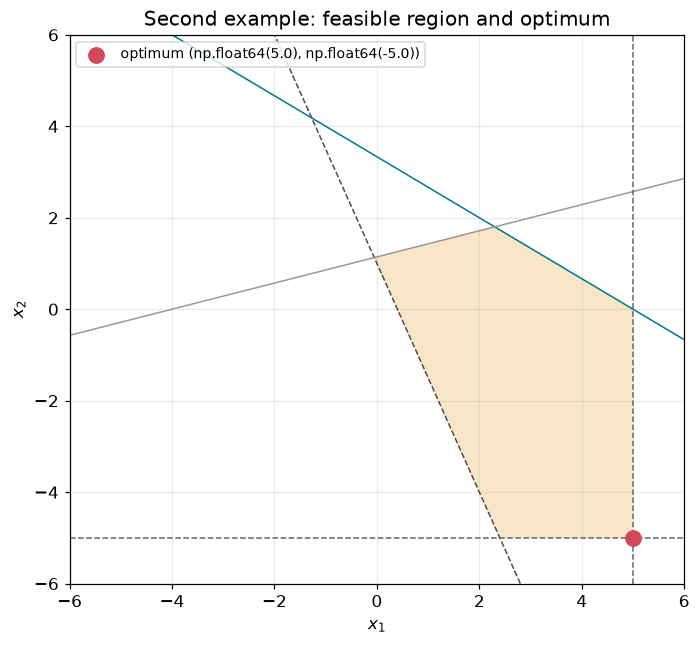

In [8]:
c2 = [-1, 1]
A_ub2 = [[2, 3], [-5, -2], [-2, 7]]
b_ub2 = [10, -2, 8]
bounds2 = [(None, 5), (-5, None)]

res2 = linprog(c2, A_ub=A_ub2, b_ub=b_ub2, bounds=bounds2, method="highs")
print("optimal x* =", res2.x, " f* =", res2.fun)

xg = np.linspace(-6, 6, 400)
X1b, X2b = np.meshgrid(xg, xg)
feas2 = (2*X1b + 3*X2b <= 10) & (-5*X1b - 2*X2b <= -2) & (-2*X1b + 7*X2b <= 8) & (X1b <= 5) & (X2b >= -5)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.contourf(X1b, X2b, feas2.astype(float), levels=[0.5, 1], colors=[COLORS["accent"]], alpha=0.3)
ax.contour(X1b, X2b, 2*X1b + 3*X2b, levels=[10], colors=[COLORS["boundary"]], linewidths=1)
ax.contour(X1b, X2b, -5*X1b - 2*X2b, levels=[-2], colors=["0.3"], linewidths=1)
ax.contour(X1b, X2b, -2*X1b + 7*X2b, levels=[8], colors=["0.6"], linewidths=1)
ax.axvline(5, color="0.4", ls="--", lw=1)
ax.axhline(-5, color="0.4", ls="--", lw=1)
ax.scatter(*res2.x, color=COLORS["optimum"], s=100, zorder=5, label=f"optimum {tuple(np.round(res2.x,2))}")
ax.set(xlim=(-6, 6), ylim=(-6, 6), xlabel="$x_1$", ylabel="$x_2$",
       title="Second example: feasible region and optimum")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Interactive: watch the pivot rule choose a different path

Change the farmer's per-acre profits and watch how the entering-variable rule (Dantzig's rule) can change which vertex the algorithm visits first - while always arriving at *an* optimal vertex.

In [ ]:
def simplex_demo(profit_corn=40.0, profit_oats=30.0):
    c_demo = [-profit_corn, -profit_oats, 0, 0]
    x_d, obj_d, hist_d = simplex_tableau(A, b, c_demo, basis=[2, 3], names=names)
    path_d = []
    for h in hist_d:
        xk = np.zeros(4)
        for i, col in enumerate(h["basis"]):
            xk[col] = h["b"][i]
        path_d.append(xk[:2])
    path_d = np.array(path_d)

    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1], colors=[COLORS["accent"]], alpha=0.3)
    ax.plot(x1g, 320 - 2*x1g, color=COLORS["boundary"], lw=1)
    ax.plot(x1g, 240 - x1g, color="0.3", lw=1)
    ax.plot(path_d[:, 0], path_d[:, 1], "-o", color=COLORS["path"], lw=2, zorder=5)
    ax.scatter(*path_d[-1], color=COLORS["optimum"], s=100, zorder=6)
    ax.set(xlim=(0, 200), ylim=(0, 260), xlabel="$x_1$", ylabel="$x_2$",
           title=f"c=(-{profit_corn:g},-{profit_oats:g}): {len(path_d)-1} pivot(s), "
                 f"optimum ({path_d[-1,0]:.0f},{path_d[-1,1]:.0f}), f={obj_d:.0f}")
    plt.tight_layout()
    plt.show()

try:
    import ipywidgets as widgets
    from IPython.display import display as ip_display
    ip_display(widgets.interactive(simplex_demo,
                                    profit_corn=widgets.FloatSlider(value=40, min=5, max=80, step=5),
                                    profit_oats=widgets.FloatSlider(value=30, min=5, max=80, step=5)))
except ImportError:
    print("ipywidgets is not installed; running the default case.")
    simplex_demo()

interactive(children=(FloatSlider(value=40.0, description='profit_corn', max=80.0, min=5.0, step=5.0), FloatSl…

---
## Takeaways

1. A pivot is a Gauss-Jordan elimination step: normalize the pivot row, then zero out the pivot column everywhere else.
2. Dantzig's rule (most negative reduced cost) picks the entering variable; the minimum-ratio test picks the leaving variable *and* guarantees the next tableau is still feasible.
3. Our from-scratch simplex reproduces the lecture's farmer's-problem tableaus exactly, including the vertex path $(0,0)\to(160,0)\to(80,160)$, and agrees with `scipy.optimize.linprog`.
4. The all-slack starting basis only works when $b\ge0$ (all inequalities are naturally satisfied at the origin). When it is not, a two-phase or Big-M method is needed to find a first feasible basis - that is not this lecture's scope, so we leaned on `scipy` for the second example.
5. Different objective coefficients can change *which* vertices simplex visits along the way, but (for these convex problems) it still terminates at a true optimum.

## Optional exercises

1. Modify `simplex_tableau` to record, at each iteration, the ratio-test candidates (not just the winner). Use it to explain what happens when two candidates tie (a hint of degeneracy issues, mentioned but not proven in the slides).
2. Trace through by hand what `simplex_tableau` would do if you swapped the starting basis to $\{x_1, s_2\}$ with $b=[160, 80]$ directly (i.e., start mid-way) - does it still reach the same optimum?
3. For the second example in Section 4, manually find one feasible starting point (by inspection or trial and error) and use it to write down what an initial *feasible* tableau would need to look like, even without fully implementing two-phase simplex.